## Training Pipeline

In [6]:
import keras
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

In [2]:
%run -i model.ipynb

In [3]:
def train_model(
    train_set,
    validation_set,
    input_shape,
    num_classes,
    learning_rate,
    batch_size,
    epochs,
    print_model_summary=False,
):
    (X_train, y_train) = train_set

    # Initialise the LeNet5 functional model
    model = lenet5Model_function(
        input_shape=input_shape,
        num_classes=num_classes,
        print_summary=print_model_summary,
    )

    # Initialise the LeNet5 sequential model
    # model = lenet5Model_sequential(
    #     input_shape=input_shape,
    #     num_classes=num_classes,
    #     print_summary=print_model_summary,
    # )

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
        loss=keras.losses.CategoricalCrossentropy(from_logits=False),
        metrics=["accuracy"],
    )

    print("\n\n")
    results = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_set,
    )

    return model, results

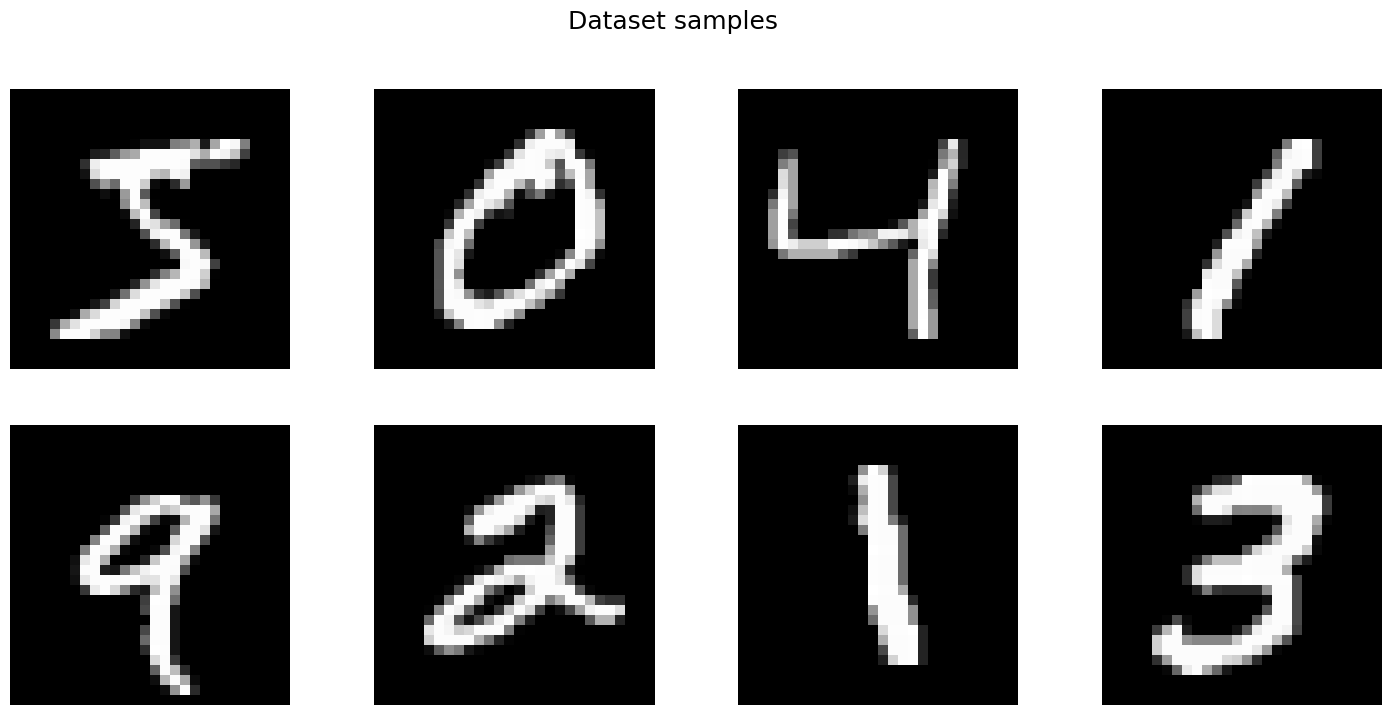



Num of training examples: 54000
Num of validation examples: 6000
Num of test examples: 10000
Image data shape: (32, 32, 1)

Data Split:

Shape X_train: (54000, 32, 32, 1) y_train: (54000, 10)
Shape X_valid: (6000, 32, 32, 1) y_valid: (6000, 10)
Shape X_test: (10000, 32, 32, 1) y_test: (10000, 10)

Ground truth labels have been one-hot encoded: 

[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1.]]


In [4]:
%run -i data_preprocessing.ipynb

In [5]:
trainingConfig = TrainingConfig()
model, training_results = train_model(
    (X_train, y_train),
    (X_valid, y_valid),
    (dataConfig.IMG_HEIGHT, dataConfig.IMG_WIDTH, dataConfig.CHANNELS),
    dataConfig.NUM_CLASSES,
    trainingConfig.LEARNING_RATE,
    trainingConfig.BATCH_SIZE,
    trainingConfig.EPOCHS,
    print_model_summary=True,
)

Model: "LeNet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10, 10, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)




Epoch 1/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8264 - loss: 0.5535 - val_accuracy: 0.9305 - val_loss: 0.2283
Epoch 2/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9531 - loss: 0.1521 - val_accuracy: 0.9662 - val_loss: 0.1078
Epoch 3/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9669 - loss: 0.1065 - val_accuracy: 0.9678 - val_loss: 0.1087
Epoch 4/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9737 - loss: 0.0841 - val_accuracy: 0.9712 - val_loss: 0.0860
Epoch 5/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9776 - loss: 0.0725 - val_accuracy: 0.9787 - val_loss: 0.0634
Epoch 6/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9808 - loss: 0.0638 - val_accuracy: 0.9815 - val_loss: 0.0571
Epoch 7/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9820 - loss: 0.0570 - val_accuracy: 0.9792 - val_loss: 0.0576
Epoch 8/21
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9839 - loss: 0.0520

### Plot Training Result

In [8]:
def plot_results(
    metrics, ylabel=None, ylim=None, xlim=None, metric_name=None, colours=None
):
    fig, ax = plt.subplots(figsize=(15, 4))

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [
            metrics,
        ]
        metric_name = [
            metric_name,
        ]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=colours[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(ylabel)
    plt.xlim(xlim)
    plt.ylim(ylim)

    # Tailor x_axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))

    plt.grid(True)
    plt.legend(metric_name)
    plt.show(block=False)
    plt.close()

In [11]:
# Print history dictionary keys
print(training_results.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


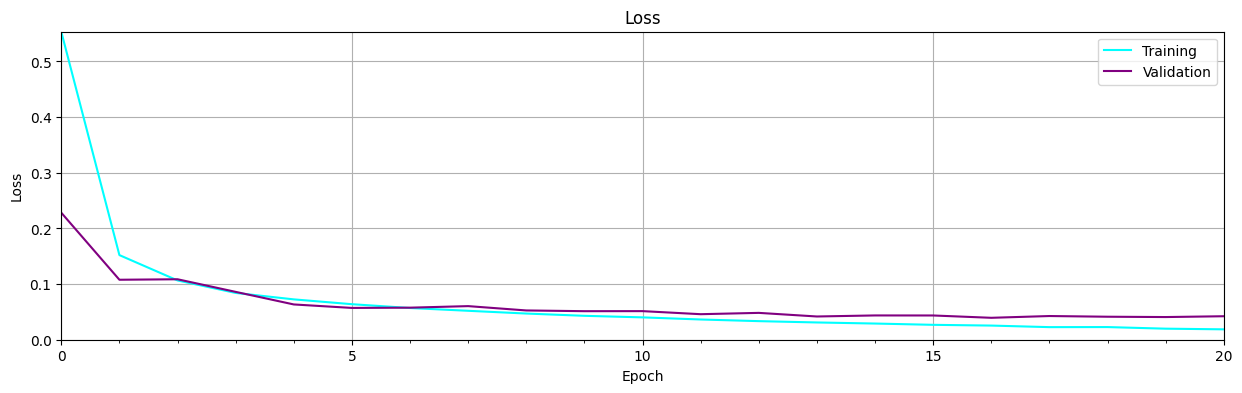

In [12]:
trainingLoss = training_results.history["loss"]
validationLoss = training_results.history["val_loss"]
maxLoss = max(max(trainingLoss), max(validationLoss))
plot_results(
    [trainingLoss, validationLoss],
    ylabel="Loss",
    ylim=[0, maxLoss],
    xlim=[0, trainingConfig.EPOCHS - 1],
    metric_name=["Training", "Validation"],
    colours=["cyan", "purple"],
)

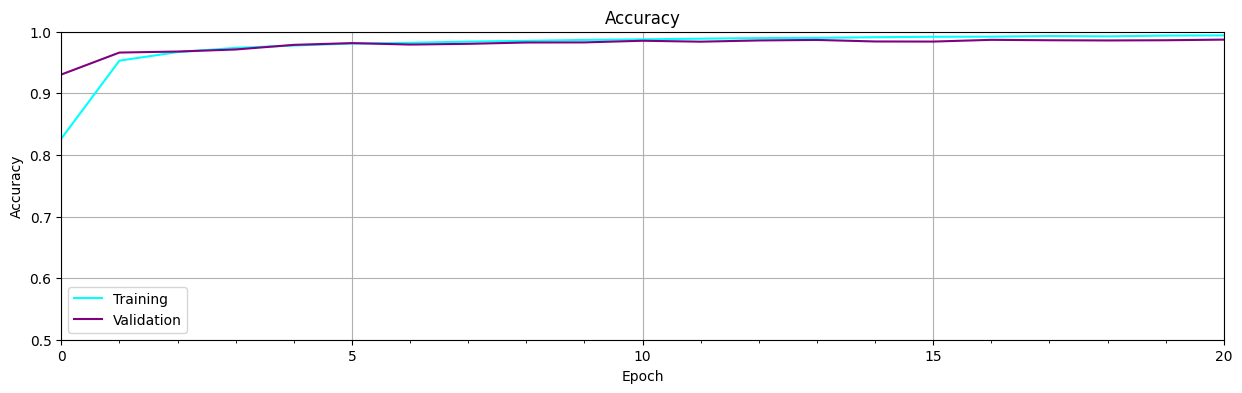

In [13]:
plot_results(
    [training_results.history["accuracy"], training_results.history["val_accuracy"]],
    ylabel="Accuracy",
    ylim=[0.5, 1.0],
    xlim=[0, trainingConfig.EPOCHS - 1],
    metric_name=["Training", "Validation"],
    colours=["cyan", "purple"],
)